# 读入数据

In [ ]:
import pandas as pd
import numpy as np
from scipy import stats

df = pd.read_csv(r"D:\VsCodeProjects\AB_Test_Analysis\data\ab_data_clean.csv")
df.head()

,user_id,timestamp,group,landing_page,converted
0,851104,2017-01-21 22:11:48.556739,control,old_page,0
1,804228,2017-01-12 08:01:45.159739,control,old_page,0
2,661590,2017-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2017-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2017-01-21 01:52:26.210827,control,old_page,1


# SRM检验

In [ ]:
from scipy.stats import chisquare as scipy_chisquare

control_n = len(df[df["group"] == "control"])
treatment_n = len(df[df["group"] == "treatment"])
total = control_n + treatment_n

observed = [control_n, treatment_n]
expected = [total / 2, total / 2]

result = scipy_chisquare(observed, expected)
chi2 = result.statistic
p = result.pvalue

print(f"Control 组人数: {control_n}")
print(f"Treatment 组人数: {treatment_n}")
print(f"Chi2统计量: {chi2:.4f}")
print(f"P值: {p:.4f}")
print(f'结论: {"⚠️ 存在SRM，分流有问题" if p < 0.05 else "✅ 无SRM，分流正常"}')

Control 组人数: 145274
Treatment 组人数: 145310
Chi2统计量: 0.0045
P值: 0.9468
结论: 无SRM，分流正常


# 样本量回算

In [ ]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

baseline_rate = df[df["group"] == "control"]["converted"].mean()
mde = 0.01

effect_size = proportion_effectsize(baseline_rate + mde, baseline_rate)

analysis = NormalIndPower()
required_n = analysis.solve_power(
    effect_size=effect_size, alpha=0.05, power=0.8, ratio=1
)

print(f"Baseline 转化率: {baseline_rate:.4f}")
print(f"最小可检测提升 (MDE): {mde:.2%}")
print(f"所需每组样本量: {int(required_n)}")
print(f"实际每组样本量: {min(control_n, treatment_n)}")
print(
    f'结论: {"样本量充足" if min(control_n, treatment_n) >= required_n else "样本量不足"}'
)

Baseline 转化率: 0.1204
最小可检测提升 (MDE): 1.00%
所需每组样本量: 17208
实际每组样本量: 145274
结论: 样本量充足


# 时间分布图

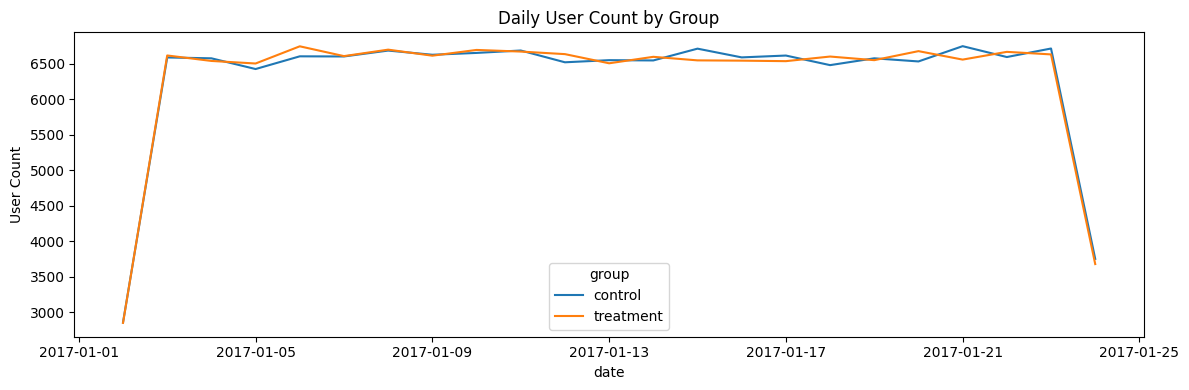

In [12]:
import matplotlib.pyplot as plt

df["timestamp"] = pd.to_datetime(df["timestamp"])
df["date"] = df["timestamp"].dt.date

daily_counts = df.groupby(["date", "group"])["user_id"].count().unstack()

daily_counts.plot(figsize=(12, 4), title="Daily User Count by Group")
plt.ylabel("User Count")
plt.tight_layout()
plt.savefig(r"D:\VsCodeProjects\AB_Test_Analysis\figures/daily_user_count.png", dpi=150)
plt.show()